In [1]:
%load_ext autotime

import scarf
scarf.__version__

'1.0.0'

time: 733 ms (started: 2026-06-25 23:22:21 +02:00)


In [2]:
!pip install -U topacedo

time: 1.2 s (started: 2026-06-25 23:22:22 +02:00)


In [3]:
# Loading preanalyzed dataset that was processed in the `basic_tutorial` vignette
scarf.fetch_dataset(
    dataset_name='tenx_5K_pbmc_rnaseq',
    as_zarr=True, 
    save_path='scarf_datasets'
)

time: 22 s (started: 2026-06-25 23:22:23 +02:00)


/home/parashar/scarf/scarf/plots.py:658: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  centers = df[[x, y, vc]].groupby(vc).median().T


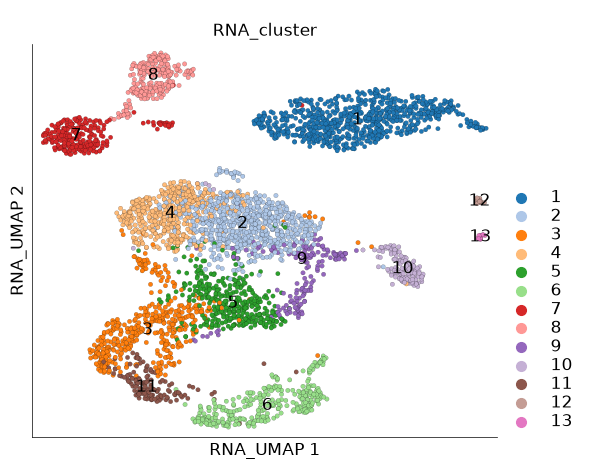

time: 3.23 s (started: 2026-06-25 23:22:45 +02:00)


In [4]:
ds = scarf.DataStore('scarf_datasets/tenx_5K_pbmc_rnaseq/data.zarr')

ds.plot_layout(
    layout_key='RNA_UMAP',
    color_by='RNA_cluster'
)

In [5]:
ds.run_topacedo_sampler(
    cluster_key='RNA_cluster',
    max_sampling_rate=0.1
)

Constructing graph from dendrogram:   0%|          | 0/3939 [00:00<?, ?it/s]

Constructing graph from dendrogram: 100%|██████████| 3939/3939 [00:00<00:00, 82464.98it/s]

INFO: 384 cells (9.75%) sub-sampled. Subsample to Seed (165 cells) ratio: 2.327


time: 2.61 s (started: 2026-06-25 23:22:48 +02:00)


/home/parashar/scarf/scarf/plots.py:658: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  centers = df[[x, y, vc]].groupby(vc).median().T


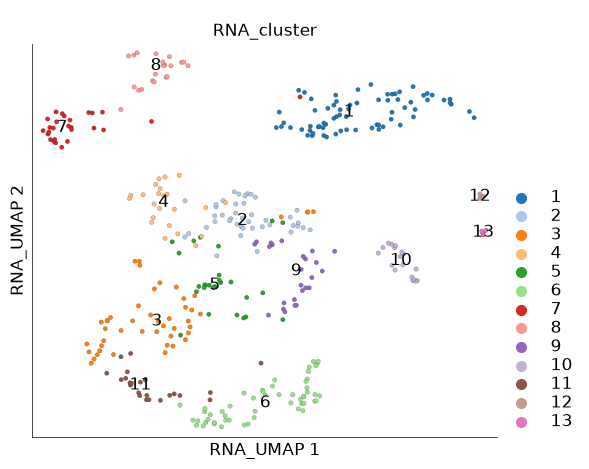

time: 1.02 s (started: 2026-06-25 23:22:51 +02:00)


In [6]:
ds.plot_layout(
    layout_key='RNA_UMAP',
    color_by='RNA_cluster',
    subselection_key='RNA_sketched'
)

/home/parashar/scarf/scarf/plots.py:658: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  centers = df[[x, y, vc]].groupby(vc).median().T


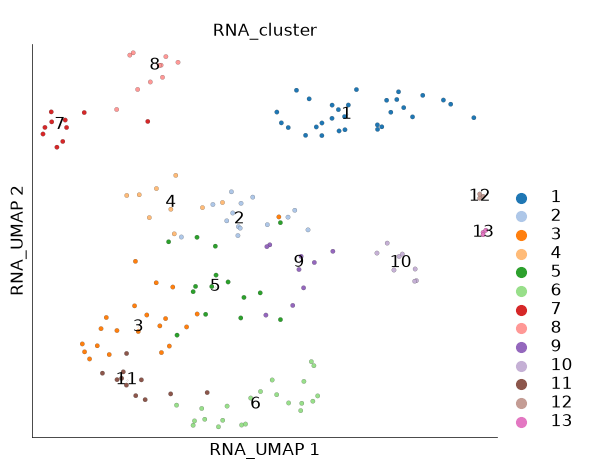

time: 898 ms (started: 2026-06-25 23:22:52 +02:00)


In [7]:
ds.plot_layout(
    layout_key='RNA_UMAP',
    color_by='RNA_cluster', 
    subselection_key='RNA_sketch_seeds'
)

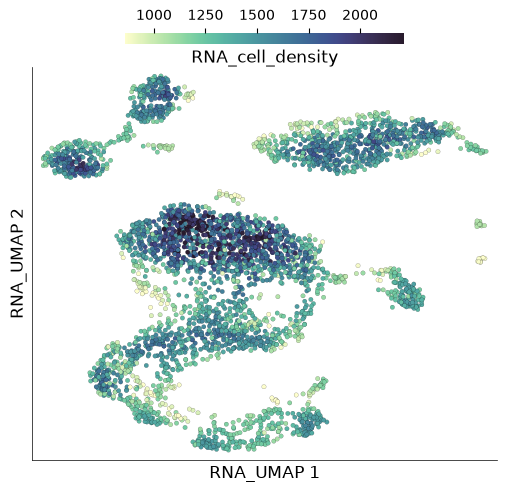

time: 773 ms (started: 2026-06-25 23:22:53 +02:00)


In [8]:
ds.plot_layout(
    layout_key='RNA_UMAP',
    color_by='RNA_cell_density'
)

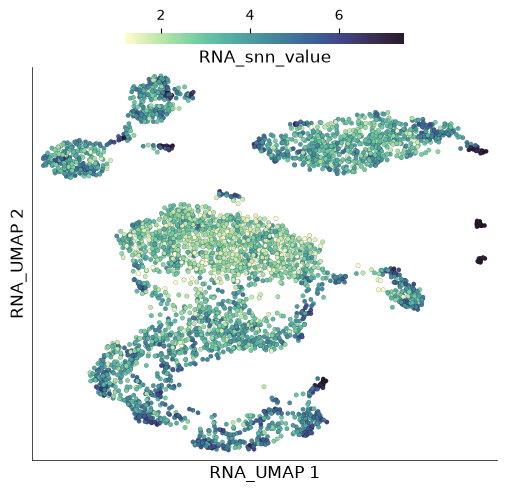

time: 833 ms (started: 2026-06-25 23:22:53 +02:00)


In [9]:
ds.plot_layout(
    layout_key='RNA_UMAP',
    color_by='RNA_snn_value'
)

In [10]:
writer = scarf.SubsetZarr(
    zarr_loc='scarf_datasets/tenx_5K_pbmc_rnaseq/subset.zarr',
    assays=[ds.RNA],
    cell_key='RNA_sketched',
    reset_cell_filter=False
)
writer.dump()

/home/parashar/scarf/.venv/lib/python3.14/site-packages/zarr/core/dtype/npy/string.py:249: UnstableSpecificationWarning: The data type (FixedLengthUTF32(length=18, endianness='little')) does not have a Zarr V3 specification. That means that the representation of arrays saved with this data type may change without warning in a future version of Zarr Python. Arrays stored with this data type may be unreadable by other Zarr libraries. Use this data type at your own risk! Check https://github.com/zarr-developers/zarr-extensions/tree/main/data-types for the status of data type specifications for Zarr V3.
  v3_unstable_dtype_warning(self)


/home/parashar/scarf/.venv/lib/python3.14/site-packages/zarr/core/dtype/npy/string.py:249: UnstableSpecificationWarning: The data type (FixedLengthUTF32(length=15, endianness='little')) does not have a Zarr V3 specification. That means that the representation of arrays saved with this data type may change without warning in a future version of Zarr Python. Arrays stored with this data type may be unreadable by other Zarr libraries. Use this data type at your own risk! Check https://github.com/zarr-developers/zarr-extensions/tree/main/data-types for the status of data type specifications for Zarr V3.
  v3_unstable_dtype_warning(self)
/home/parashar/scarf/.venv/lib/python3.14/site-packages/zarr/core/dtype/npy/string.py:249: UnstableSpecificationWarning: The data type (FixedLengthUTF32(length=16, endianness='little')) does not have a Zarr V3 specification. That means that the representation of arrays saved with this data type may change without warning in a future version of Zarr Python. 

Subsetting assay: RNA:   0%|                                                                                  …

time: 2.95 s (started: 2026-06-25 23:22:54 +02:00)


In [11]:
ds2 = scarf.DataStore('scarf_datasets/tenx_5K_pbmc_rnaseq/subset.zarr')

(RNA) Computing nCells and dropOuts:   0%|                                                                    …

(RNA) Computing RNA_percentMito:   0%|                                                                        …

(RNA) Computing RNA_percentRibo:   0%|                                                                        …

time: 1.31 s (started: 2026-06-25 23:22:57 +02:00)


In [12]:
ds2

DataStore has 384 (384) cells with 1 assays: RNA
   Cell metadata:
            'I', 'ids', 'names', 'RNA_tSNE2', 'RNA_snn_value', 
            'RNA_sketch_seeds', 'RNA_nFeatures', 'RNA_percentRibo', 'RNA_tSNE1', 'RNA_percentMito', 
            'RNA_cell_density', 'RNA_nCounts', 'RNA_UMAP2', 'RNA_leiden_cluster', 'RNA_UMAP1', 
            'RNA_cluster', 'RNA_sketched'
   RNA assay has 8773 (33538) features and following metadata:
            'I', 'ids', 'names', 'nCells', 'dropOuts', 
          

time: 167 ms (started: 2026-06-25 23:22:58 +02:00)


In [13]:
!pip install anndata

time: 1.28 s (started: 2026-06-25 23:22:59 +02:00)


In [14]:
adata = ds2.to_anndata()

ERROR: Package anndata is not installed because its an optional dependency. Install via `pip install anndata` or `conda install anndata -c conda-forge`


time: 3.97 ms (started: 2026-06-25 23:23:00 +02:00)


In [15]:
adata

time: 239 μs (started: 2026-06-25 23:23:00 +02:00)
